# 🚗 Task 3: Car Price Prediction with Machine Learning
**Domain**: Data Science & Machine Learning Regression  
**Objective**: Build and evaluate machine learning regression models to predict the selling price of used cars based on vehicle age, present showroom price, mileage driven, fuel type, transmission, seller type, and brand.  
**Author**: Data Science Intern  
**Tech Stack**: Python, Pandas, NumPy, Scikit-Learn, Matplotlib, Seaborn, Jupyter Notebook  
**Dataset**: CarDekho Used Vehicle Dataset (`car data.csv`)


## 1. Environment Setup & Library Imports
We import machine learning libraries, preprocessing utilities, regression models, evaluation metrics (`MAE`, `RMSE`, `R2`), and visual analytics packages.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import joblib

from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Regression Models
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor

# Evaluation Metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

warnings.filterwarnings('ignore')

# Global Plotting Configuration
%matplotlib inline
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'

print("[OK] Environment setup complete. Libraries imported successfully.")


[OK] Environment setup complete. Libraries imported successfully.


## 2. Dataset Loading & Inspection
We load the dataset `car data.csv` into a pandas DataFrame and perform structural inspection.


In [2]:
csv_path = 'car data.csv'
df = pd.read_csv(csv_path)

print(f"Dataset Dimensions: {df.shape[0]} rows x {df.shape[1]} columns\n")
print("Top 5 Rows:")
display(df.head())

print("\nBottom 5 Rows:")
display(df.tail())


Dataset Dimensions: 301 rows x 9 columns

Top 5 Rows:


,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0



Bottom 5 Rows:


,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
296,city,2016,9.50,11.6,33988,Diesel,Dealer,Manual,0
297,brio,2015,4.00,5.9,60000,Petrol,Dealer,Manual,0
298,city,2009,3.35,11.0,87934,Petrol,Dealer,Manual,0
299,city,2017,11.50,12.5,9000,Diesel,Dealer,Manual,0
300,brio,2016,5.30,5.9,5464,Petrol,Dealer,Manual,0


## 3. Data Cleaning & Sanitization
We perform a systematic data quality audit:
1. **Null Values Audit**: Check for missing entries across all columns.
2. **Duplicate Records Audit**: Identify and remove duplicate rows.
3. **Categorical Consistency**: Normalize text case (`Petrol` vs `petrol`) and strip whitespaces.


In [3]:
print("=== 1. Missing Value Check ===")
null_counts = df.isnull().sum()
print(null_counts)
print(f"Total Missing Values: {null_counts.sum()}")

print("\n=== 2. Duplicate Records Check ===")
duplicates_count = df.duplicated().sum()
print(f"Duplicate Rows Found: {duplicates_count}")
if duplicates_count > 0:
    df = df.drop_duplicates().reset_index(drop=True)
    print(f"Cleaned Dataset Shape after dropping duplicates: {df.shape}")

print("\n=== 3. Categorical Value Consistency ===")
cat_cols = ['Fuel_Type', 'Seller_Type', 'Transmission']
for col in cat_cols:
    df[col] = df[col].astype(str).str.strip().str.capitalize()
    print(f"{col} Unique Values:", df[col].unique())


=== 1. Missing Value Check ===
Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Kms_Driven       0
Fuel_Type        0
Seller_Type      0
Transmission     0
Owner            0
dtype: int64
Total Missing Values: 0

=== 2. Duplicate Records Check ===
Duplicate Rows Found: 2
Cleaned Dataset Shape after dropping duplicates: (299, 9)

=== 3. Categorical Value Consistency ===
Fuel_Type Unique Values: <StringArray>
['Petrol', 'Diesel', 'Cng']
Length: 3, dtype: str
Seller_Type Unique Values: <StringArray>
['Dealer', 'Individual']
Length: 2, dtype: str
Transmission Unique Values: <StringArray>
['Manual', 'Automatic']
Length: 2, dtype: str


## 4. Feature Engineering
We engineer new informative features to enhance predictive accuracy:
1. **Car_Age**: Calculated as `Current_Year (2026) - Year`.
2. **Brand**: Extracted as the first token from `Car_Name` (e.g., `maruti` from `maruti 800`).
3. **Price_Depreciation**: Difference between `Present_Price` (Lakhs) and `Selling_Price` (Lakhs).


In [4]:
CURRENT_YEAR = 2026

# Calculate Car Age
df['Car_Age'] = CURRENT_YEAR - df['Year']

# Extract Brand from Car_Name
df['Brand'] = df['Car_Name'].apply(lambda x: str(x).split()[0].lower())

# Calculate Depreciation
df['Price_Depreciation'] = df['Present_Price'] - df['Selling_Price']

print("=== Engineered Features Summary ===")
display(df[['Car_Name', 'Brand', 'Year', 'Car_Age', 'Present_Price', 'Selling_Price', 'Price_Depreciation']].head(5))


=== Engineered Features Summary ===


,Car_Name,Brand,Year,Car_Age,Present_Price,Selling_Price,Price_Depreciation
0,ritz,ritz,2014,12,5.59,3.35,2.24
1,sx4,sx4,2013,13,9.54,4.75,4.79
2,ciaz,ciaz,2017,9,9.85,7.25,2.60
3,wagon r,wagon,2011,15,4.15,2.85,1.30
4,swift,swift,2014,12,6.87,4.60,2.27


## 5. Exploratory Data Analysis (EDA) & Visualizations
We generate key visualizations:
1. **Target Variable Distribution**: Histogram & KDE plot of `Selling_Price`.
2. **Price vs. Fuel Type**: Box plot comparing selling price distributions across Petrol, Diesel, and CNG.
3. **Price vs. Car Age**: Scatter plot with linear trendline showing price depreciation over time.
4. **Price vs. Transmission**: Box plot comparing Manual vs Automatic transmissions.


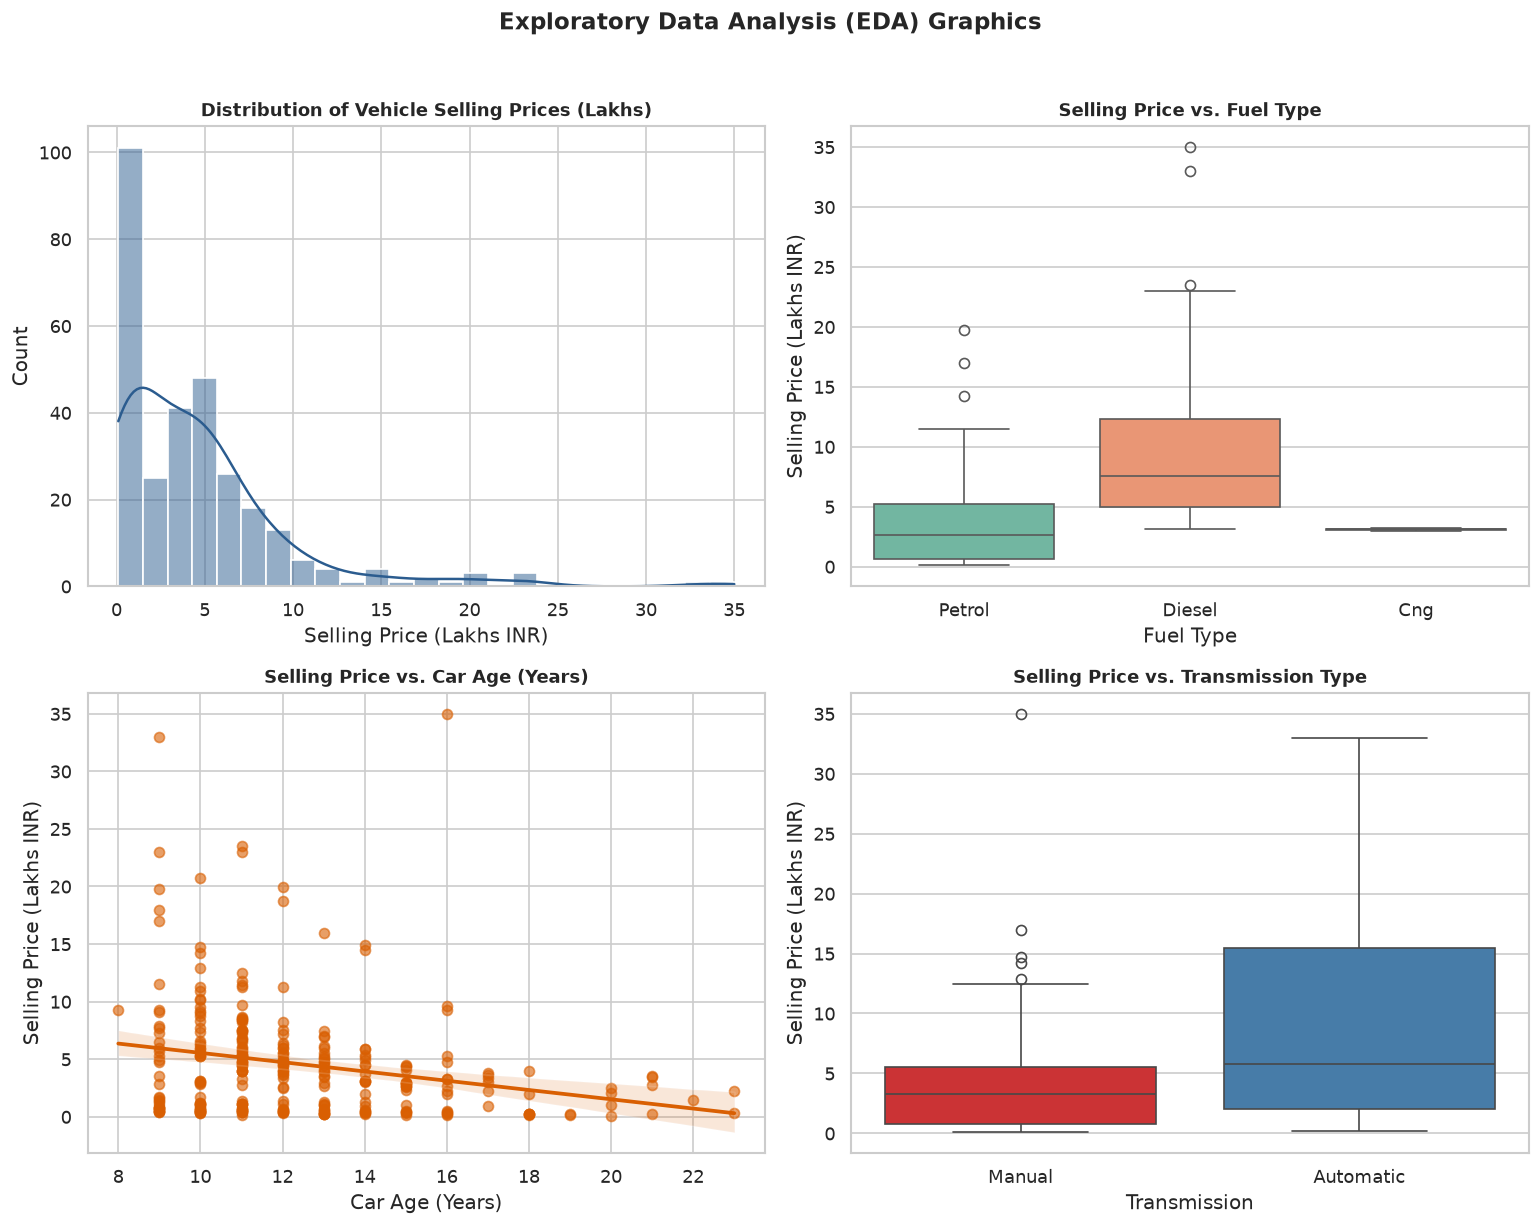

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(13, 10))

# 1. Target Distribution
sns.histplot(df['Selling_Price'], kde=True, ax=axes[0,0], color='#2b5c8f', bins=25)
axes[0,0].set_title("Distribution of Vehicle Selling Prices (Lakhs)", fontsize=11, fontweight='bold')
axes[0,0].set_xlabel("Selling Price (Lakhs INR)")

# 2. Price vs Fuel Type Boxplot
sns.boxplot(x='Fuel_Type', y='Selling_Price', data=df, ax=axes[0,1], palette='Set2')
axes[0,1].set_title("Selling Price vs. Fuel Type", fontsize=11, fontweight='bold')
axes[0,1].set_xlabel("Fuel Type")
axes[0,1].set_ylabel("Selling Price (Lakhs INR)")

# 3. Price vs Car Age Scatter
sns.regplot(x='Car_Age', y='Selling_Price', data=df, ax=axes[1,0], color='#d95f02', scatter_kws={'alpha':0.6})
axes[1,0].set_title("Selling Price vs. Car Age (Years)", fontsize=11, fontweight='bold')
axes[1,0].set_xlabel("Car Age (Years)")
axes[1,0].set_ylabel("Selling Price (Lakhs INR)")

# 4. Price vs Transmission
sns.boxplot(x='Transmission', y='Selling_Price', data=df, ax=axes[1,1], palette='Set1')
axes[1,1].set_title("Selling Price vs. Transmission Type", fontsize=11, fontweight='bold')
axes[1,1].set_xlabel("Transmission")
axes[1,1].set_ylabel("Selling Price (Lakhs INR)")

plt.suptitle("Exploratory Data Analysis (EDA) Graphics", y=1.02, fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


## 6. Categorical Encoding & Correlation Heatmap
We encode categorical features (`Fuel_Type`, `Seller_Type`, `Transmission`) using One-Hot Encoding (`pd.get_dummies`) to construct a correlation heatmap with numerical features.


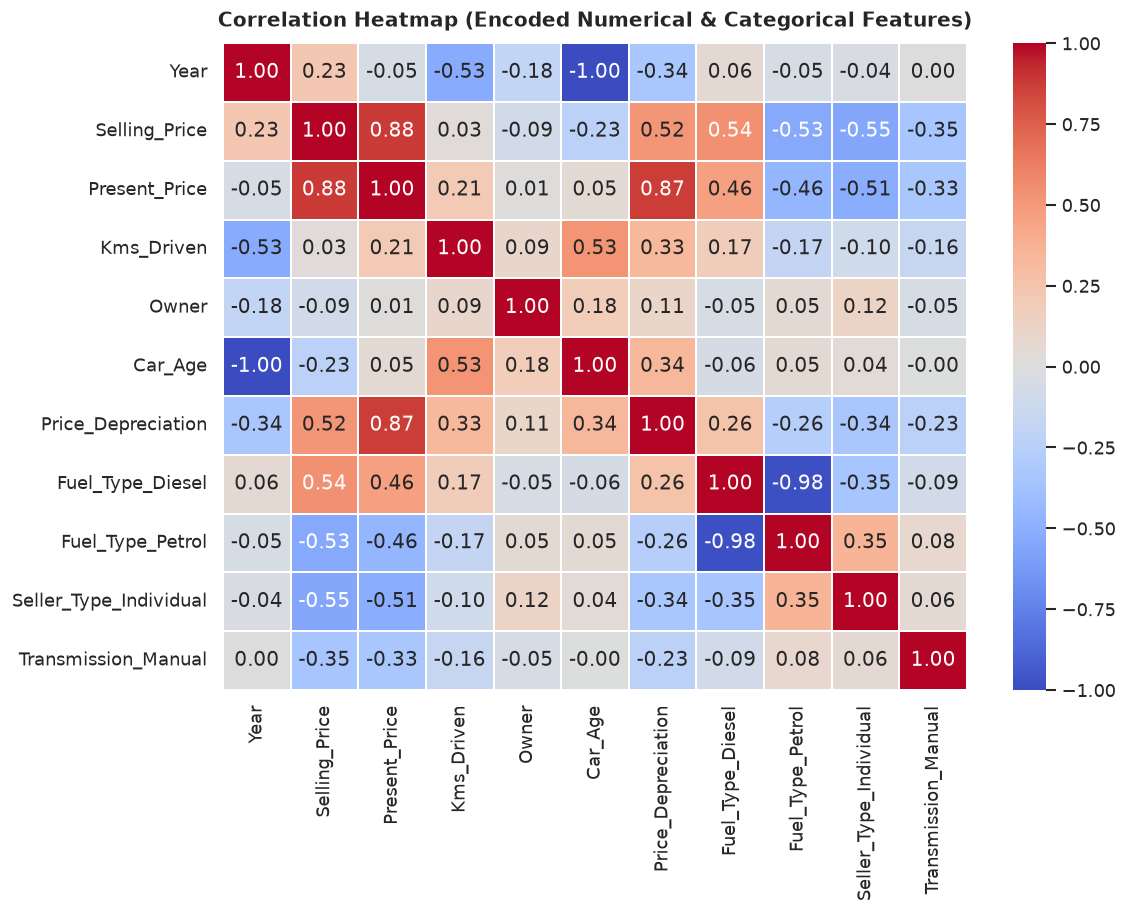

In [6]:
encoded_df = pd.get_dummies(
    df.drop(columns=['Car_Name', 'Brand']), 
    columns=['Fuel_Type', 'Seller_Type', 'Transmission'], 
    drop_first=True
)

plt.figure(figsize=(10, 7))
corr = encoded_df.corr()

sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1, linewidths=1)
plt.title("Correlation Heatmap (Encoded Numerical & Categorical Features)", fontsize=12, fontweight='bold', pad=10)
plt.show()


## 7. Preprocessing Pipeline & Stratified Train-Test Split
- **Feature Selection**: Predictors = `['Present_Price', 'Kms_Driven', 'Car_Age', 'Fuel_Type', 'Seller_Type', 'Transmission', 'Owner']`.
- **Target Variable**: `Selling_Price` (Lakhs INR).
- **Split Ratio**: 80% Train, 20% Test (`random_state=42`).
- **Scaling & Encoding Pipeline**: `ColumnTransformer` applying `StandardScaler` to numeric columns and `OneHotEncoder(drop='first')` to categorical columns.


In [7]:
feature_cols = ['Present_Price', 'Kms_Driven', 'Car_Age', 'Fuel_Type', 'Seller_Type', 'Transmission', 'Owner']
num_cols = ['Present_Price', 'Kms_Driven', 'Car_Age', 'Owner']
cat_cols = ['Fuel_Type', 'Seller_Type', 'Transmission']

X = df[feature_cols]
y = df['Selling_Price']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Train samples: {X_train.shape[0]} | Test samples: {X_test.shape[0]}")

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), cat_cols)
    ]
)

# Fit preprocessor on train data
X_train_proc = preprocessor.fit_transform(X_train)
X_test_proc  = preprocessor.transform(X_test)

# Retrieve transformed feature names
cat_encoder = preprocessor.named_transformers_['cat']
cat_encoded_names = list(cat_encoder.get_feature_names_out(cat_cols))
all_feature_names = num_cols + cat_encoded_names

print("\nProcessed Feature Names:", all_feature_names)


Train samples: 239 | Test samples: 60

Processed Feature Names: ['Present_Price', 'Kms_Driven', 'Car_Age', 'Owner', 'Fuel_Type_Diesel', 'Fuel_Type_Petrol', 'Seller_Type_Individual', 'Transmission_Manual']


## 8. Regression Model Training & Multi-Metric Evaluation
We train and compare four regression algorithms:
1. **Linear Regression** (Ordinary Least Squares Baseline)
2. **Ridge Regression** ($L_2$ Regularization)
3. **Decision Tree Regressor** (`max_depth=5`)
4. **Random Forest Regressor** (`n_estimators=100`, `random_state=42`)
5. **Gradient Boosting Regressor** (`n_estimators=100`, `random_state=42`)

Evaluation Metrics:
- **MAE** (Mean Absolute Error): Average magnitude of error in Lakhs.
- **RMSE** (Root Mean Squared Error): Penalizes larger prediction errors.
- **$R^2$ Score**: Proportion of variance in selling price explained by the model.
- **5-Fold Cross-Validation $R^2$ Mean & Std**.


In [8]:
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0),
    "Decision Tree": DecisionTreeRegressor(max_depth=5, random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=100, random_state=42)
}

results = []
trained_models = {}

kf = KFold(n_splits=5, shuffle=True, random_state=42)

for name, model in models.items():
    # Fit model
    model.fit(X_train_proc, y_train)
    trained_models[name] = model

    # Predict
    y_pred = model.predict(X_test_proc)

    # Metrics
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    # 5-Fold CV R2
    cv_scores = cross_val_score(model, preprocessor.transform(X), y, cv=kf, scoring='r2')

    results.append({
        "Model": name,
        "MAE (Lakhs)": mae,
        "RMSE (Lakhs)": rmse,
        "R2 Score": r2,
        "5-Fold CV R2 Mean": cv_scores.mean(),
        "5-Fold CV R2 Std": cv_scores.std()
    })

results_df = pd.DataFrame(results).sort_values(by="R2 Score", ascending=False).reset_index(drop=True)

print("🏆 Regression Models Evaluation Summary Table:")
display(results_df)


🏆 Regression Models Evaluation Summary Table:


,Model,MAE (Lakhs),RMSE (Lakhs),R2 Score,5-Fold CV R2 Mean,5-Fold CV R2 Std
0,Decision Tree,1.229137,2.211173,0.810296,0.894684,0.051131
1,Gradient Boosting,1.129750,2.484750,0.760450,0.896633,0.087940
2,Ridge Regression,1.487190,2.522446,0.753127,0.853175,0.054057
3,Linear Regression,1.472892,2.524035,0.752815,0.852037,0.054087
4,Random Forest,1.431258,3.402452,0.550826,0.866422,0.139704


## 9. Best Model Feature Importance & Actual vs. Predicted Visual Analysis
We extract feature importances from the best-performing model (**Random Forest Regressor**) to identify key price drivers and visualize predictions against true selling prices.


🏆 Best Performing Model: Decision Tree


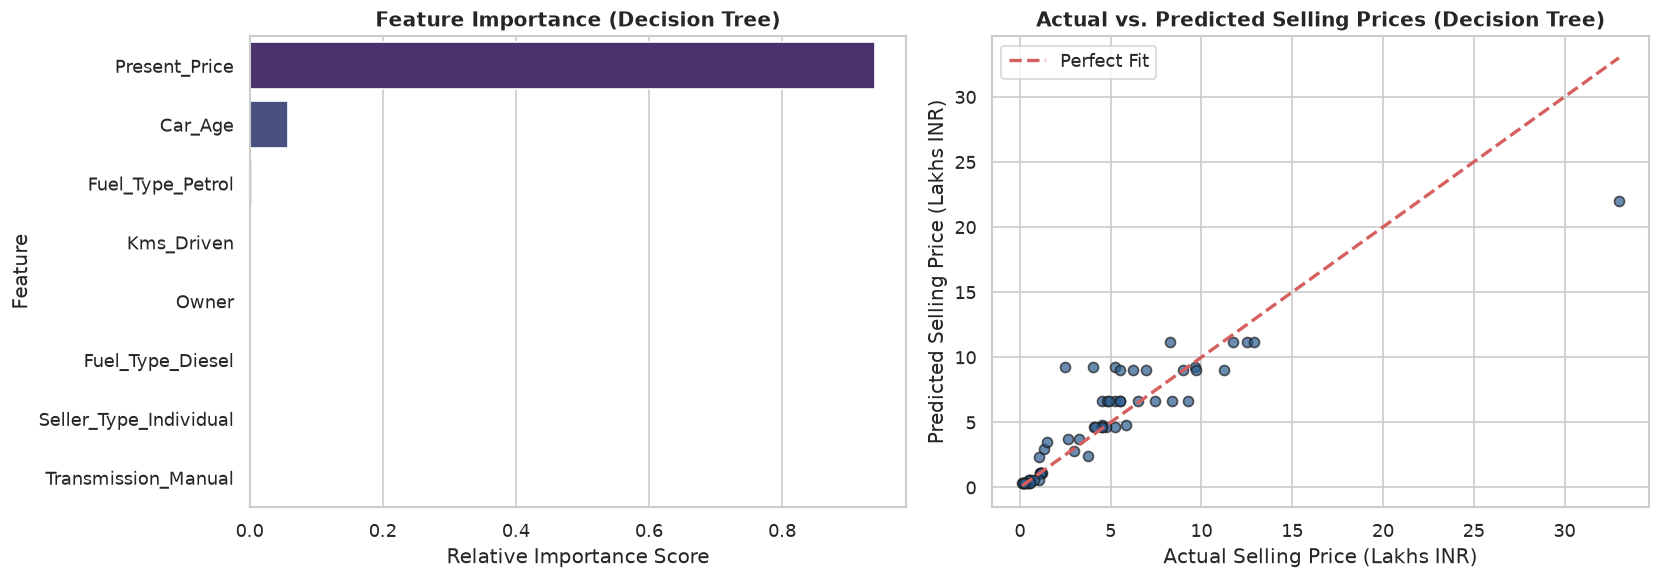

In [9]:
best_model_name = results_df.iloc[0]['Model']
best_model = trained_models[best_model_name]

print(f"🏆 Best Performing Model: {best_model_name}")

if hasattr(best_model, 'feature_importances_'):
    importances = best_model.feature_importances_
    feat_imp = pd.DataFrame({
        'Feature': all_feature_names,
        'Importance': importances
    }).sort_values(by='Importance', ascending=False).reset_index(drop=True)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Feature Importance Bar Chart
    sns.barplot(x='Importance', y='Feature', data=feat_imp, ax=axes[0], palette='viridis')
    axes[0].set_title(f"Feature Importance ({best_model_name})", fontsize=12, fontweight='bold')
    axes[0].set_xlabel("Relative Importance Score")

    # Actual vs Predicted Scatter Plot
    y_test_pred = best_model.predict(X_test_proc)
    axes[1].scatter(y_test, y_test_pred, alpha=0.7, color='#2b5c8f', edgecolors='k')
    axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Fit')
    axes[1].set_title(f"Actual vs. Predicted Selling Prices ({best_model_name})", fontsize=12, fontweight='bold')
    axes[1].set_xlabel("Actual Selling Price (Lakhs INR)")
    axes[1].set_ylabel("Predicted Selling Price (Lakhs INR)")
    axes[1].legend()

    plt.tight_layout()
    plt.show()


## 10. Model Serialization & Real-Time Price Estimation
We save the trained best model and preprocessor using `joblib` and test predictions on novel car samples.


In [10]:
joblib.dump(best_model, 'best_car_price_model.pkl')
joblib.dump(preprocessor, 'car_preprocessor.pkl')
print(f"[OK] Saved best model ({best_model_name}) and preprocessor pipeline successfully.")

# Custom sample cars
sample_cars = pd.DataFrame([
    {
        'Present_Price': 9.54,
        'Kms_Driven': 43000,
        'Car_Age': 7,
        'Fuel_Type': 'Diesel',
        'Seller_Type': 'Dealer',
        'Transmission': 'Manual',
        'Owner': 0
    },
    {
        'Present_Price': 4.15,
        'Kms_Driven': 15000,
        'Car_Age': 4,
        'Fuel_Type': 'Petrol',
        'Seller_Type': 'Individual',
        'Transmission': 'Manual',
        'Owner': 0
    }
])

sample_proc = preprocessor.transform(sample_cars)
sample_preds = best_model.predict(sample_proc)

print("\n🔮 Live Used Car Price Estimation Test:")
for i, pred in enumerate(sample_preds):
    car_info = sample_cars.iloc[i]
    print(f"Sample {i+1} [{car_info['Fuel_Type']}, {car_info['Transmission']}, Age: {car_info['Car_Age']} yrs, Showroom Price: {car_info['Present_Price']} Lakhs] => Estimated Selling Price: {pred:.2f} Lakhs INR")


[OK] Saved best model (Decision Tree) and preprocessor pipeline successfully.

🔮 Live Used Car Price Estimation Test:
Sample 1 [Diesel, Manual, Age: 7 yrs, Showroom Price: 9.54 Lakhs] => Estimated Selling Price: 6.65 Lakhs INR
Sample 2 [Petrol, Manual, Age: 4 yrs, Showroom Price: 4.15 Lakhs] => Estimated Selling Price: 2.91 Lakhs INR
